# CSV Image Generation Notebook

In [1]:
from pathlib import Path
import json
import math
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)

# Change this if you want to target a specific file.
CSV_PATH = Path("../bedrock_recipe_model_results.csv")

if not CSV_PATH.exists():
    raise FileNotFoundError("Could not find a supported CSV file.")

print(f"Using CSV: {CSV_PATH}")

Using CSV: ..\bedrock_recipe_model_results.csv


In [2]:
df = pd.read_csv(CSV_PATH)
print("Shape:", df.shape)
display(df.head())
print("\nColumns:")
for c in df.columns:
    print(" ", c)

Shape: (918, 23)


,recipe_id,source_file,model_label,model_id,temperature,latency_sec,input_tokens,output_tokens,total_tokens,run_cost_usd,...,field_accuracy,allowed_values_score,overall_score,schema_errors,allowed_value_errors,field_scores_json,expected_output,raw_output,parsed_output,error
0,14591,jordan_labeled.csv,Amazon Nova Micro,amazon.nova-micro-v1:0,0.1,0.8070,749,56,805,0.000034,...,0.6500,0.25,82.0965,NaN,cuisine contains invalid values | allergens co...,"{""recipe_id"": 1.0, ""cuisine"": 0.0, ""meal_type""...","{""recipe_id"": ""14591"", ""cuisine"": [""American""]...","{\r\n ""recipe_id"": ""14591"",\r\n ""cuisine"": [...","{""recipe_id"": ""14591"", ""cuisine"": [""Canadian""]...",NaN
1,14591,jordan_labeled.csv,Amazon Nova Micro,amazon.nova-micro-v1:0,0.3,0.4059,749,52,801,0.000034,...,0.6000,0.25,79.7970,NaN,cuisine contains invalid values | allergens co...,"{""recipe_id"": 1.0, ""cuisine"": 0.0, ""meal_type""...","{""recipe_id"": ""14591"", ""cuisine"": [""American""]...","{\r\n ""recipe_id"": ""14591"",\r\n ""cuisine"": [...","{""recipe_id"": ""14591"", ""cuisine"": [""Canadian""]...",NaN
2,14591,jordan_labeled.csv,Amazon Nova Micro,amazon.nova-micro-v1:0,0.5,0.4021,749,52,801,0.000034,...,0.6000,0.25,79.7990,NaN,cuisine contains invalid values | allergens co...,"{""recipe_id"": 1.0, ""cuisine"": 0.0, ""meal_type""...","{""recipe_id"": ""14591"", ""cuisine"": [""American""]...","{\r\n ""recipe_id"": ""14591"",\r\n ""cuisine"": [...","{""recipe_id"": ""14591"", ""cuisine"": [""Canadian""]...",NaN
3,14591,jordan_labeled.csv,Anthropic Claude 3.5 Haiku,us.anthropic.claude-3-5-haiku-20241022-v1:0,0.1,1.2758,882,58,940,0.000938,...,0.7333,0.50,86.0288,NaN,cuisine contains invalid values | cooking_meth...,"{""recipe_id"": 1.0, ""cuisine"": 0.0, ""meal_type""...","{""recipe_id"": ""14591"", ""cuisine"": [""American""]...","{\r\n ""recipe_id"": ""14591"",\r\n ""cuisine"": [...","{""recipe_id"": ""14591"", ""cuisine"": [""Canadian""]...",NaN
4,14591,jordan_labeled.csv,Anthropic Claude 3.5 Haiku,us.anthropic.claude-3-5-haiku-20241022-v1:0,0.3,1.3597,882,58,940,0.000938,...,0.7333,0.50,85.9868,NaN,cuisine contains invalid values | cooking_meth...,"{""recipe_id"": 1.0, ""cuisine"": 0.0, ""meal_type""...","{""recipe_id"": ""14591"", ""cuisine"": [""American""]...","{\r\n ""recipe_id"": ""14591"",\r\n ""cuisine"": [...","{""recipe_id"": ""14591"", ""cuisine"": [""Canadian""]...",NaN



Columns:
  recipe_id
  source_file
  model_label
  model_id
  temperature
  latency_sec
  input_tokens
  output_tokens
  total_tokens
  run_cost_usd
  stop_reason
  valid_json
  valid_schema
  field_accuracy
  allowed_values_score
  overall_score
  schema_errors
  allowed_value_errors
  field_scores_json
  expected_output
  raw_output
  parsed_output
  error


In [3]:
def safe_series_exists(column_name: str) -> bool:
    return column_name in df.columns

def grouped_bar(series, title, xlabel, ylabel, filename, rotation=20):
    ax = series.plot(kind="bar")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=rotation, ha="right")

## Auto detect the CSV type

In [4]:
is_results = {"model_label", "overall_score", "latency_sec", "run_cost_usd"}.issubset(df.columns)
is_summary = {"model_label", "avg_overall_score", "avg_latency_sec", "value_index"}.issubset(df.columns)

print("Results CSV detected:", is_results)
print("Summary CSV detected:", is_summary)

if not is_results and not is_summary:
    print("This notebook did not detect a known schema. The generic section at the end may still help.")

Results CSV detected: True
Summary CSV detected: False


## Charts for `bedrock_recipe_model_results.csv`

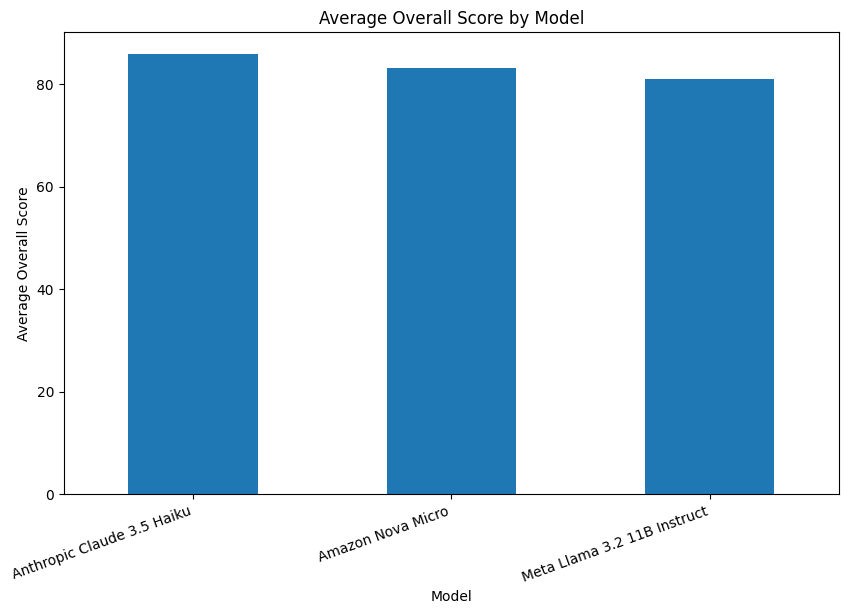

In [5]:
if is_results:
    score_by_model = (
        df.groupby("model_label", dropna=False)["overall_score"]
        .mean()
        .sort_values(ascending=False)
    )
    grouped_bar(
        score_by_model,
        "Average Overall Score by Model",
        "Model",
        "Average Overall Score",
        "results_avg_overall_score_by_model.png"
    )

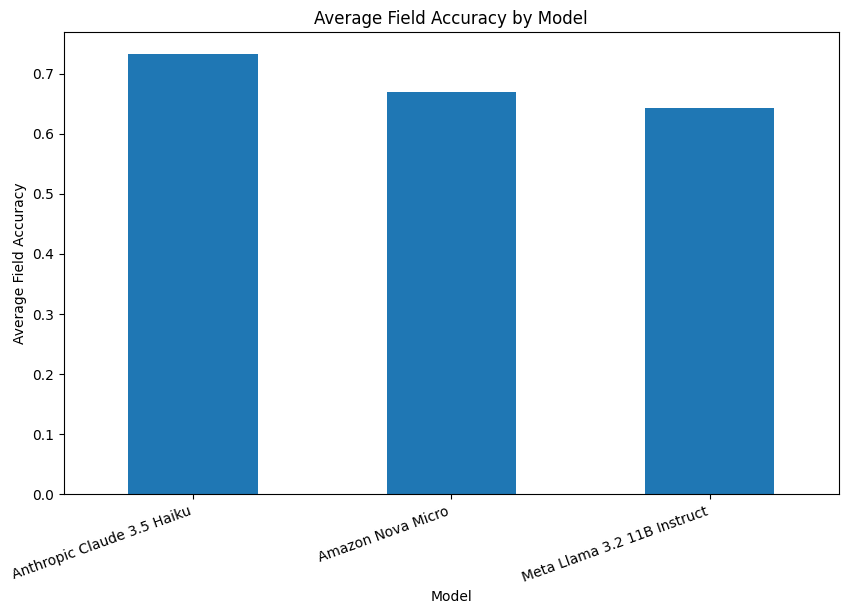

In [6]:
if is_results and safe_series_exists("field_accuracy"):
    accuracy_by_model = (
        df.groupby("model_label", dropna=False)["field_accuracy"]
        .mean()
        .sort_values(ascending=False)
    )
    grouped_bar(
        accuracy_by_model,
        "Average Field Accuracy by Model",
        "Model",
        "Average Field Accuracy",
        "results_avg_field_accuracy_by_model.png"
    )

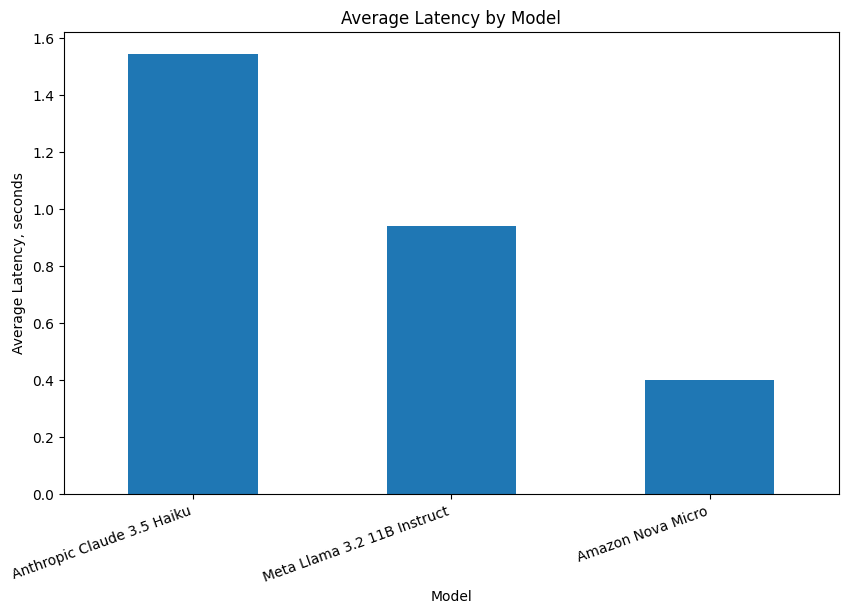

In [7]:
if is_results and safe_series_exists("latency_sec"):
    latency_by_model = (
        df.groupby("model_label", dropna=False)["latency_sec"]
        .mean()
        .sort_values(ascending=False)
    )
    grouped_bar(
        latency_by_model,
        "Average Latency by Model",
        "Model",
        "Average Latency, seconds",
        "results_avg_latency_by_model.png"
    )

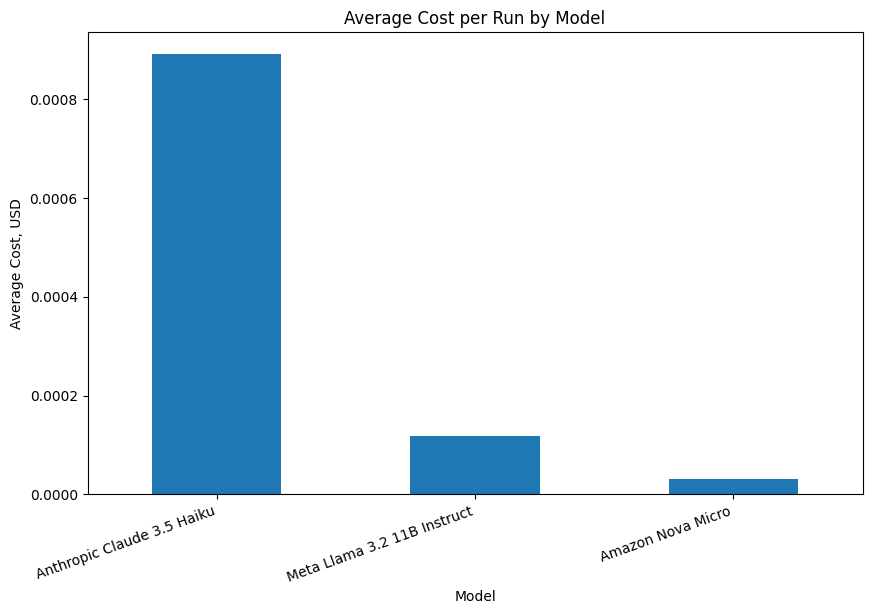

In [8]:
if is_results and safe_series_exists("run_cost_usd"):
    cost_by_model = (
        df.groupby("model_label", dropna=False)["run_cost_usd"]
        .mean()
        .sort_values(ascending=False)
    )
    grouped_bar(
        cost_by_model,
        "Average Cost per Run by Model",
        "Model",
        "Average Cost, USD",
        "results_avg_cost_by_model.png"
    )

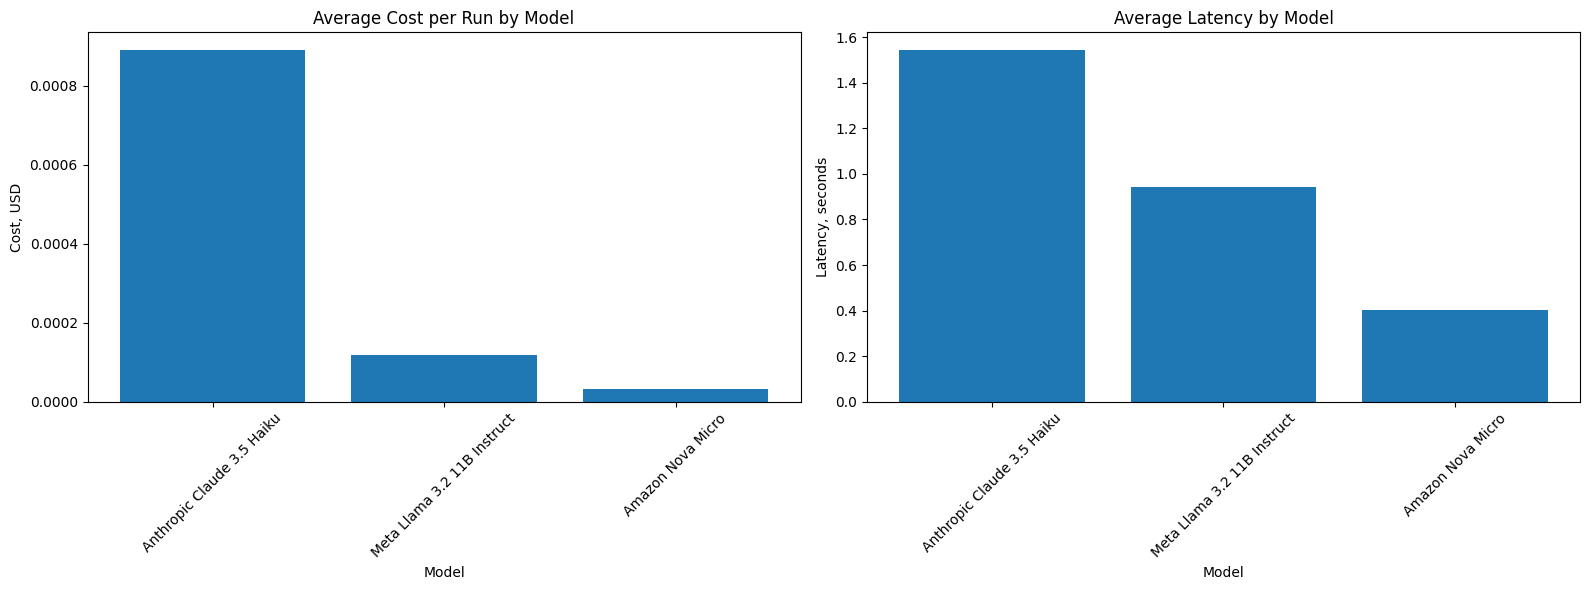

In [9]:
import matplotlib.pyplot as plt

if is_results and all(safe_series_exists(col) for col in ["model_label", "run_cost_usd", "latency_sec"]):

    # Aggregate
    combined = (
        df.groupby("model_label", dropna=False)
        .agg(
            avg_cost=("run_cost_usd", "mean"),
            avg_latency=("latency_sec", "mean")
        )
        .sort_values("avg_cost", ascending=False)
    )

    models = combined.index.tolist()

    # Create side by side plots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Cost plot
    axes[0].bar(models, combined["avg_cost"])
    axes[0].set_title("Average Cost per Run by Model")
    axes[0].set_xlabel("Model")
    axes[0].set_ylabel("Cost, USD")
    axes[0].tick_params(axis="x", rotation=45)

    # Latency plot
    axes[1].bar(models, combined["avg_latency"])
    axes[1].set_title("Average Latency by Model")
    axes[1].set_xlabel("Model")
    axes[1].set_ylabel("Latency, seconds")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.savefig("results_cost_latency_side_by_side.png", dpi=200, bbox_inches="tight")
    plt.show()

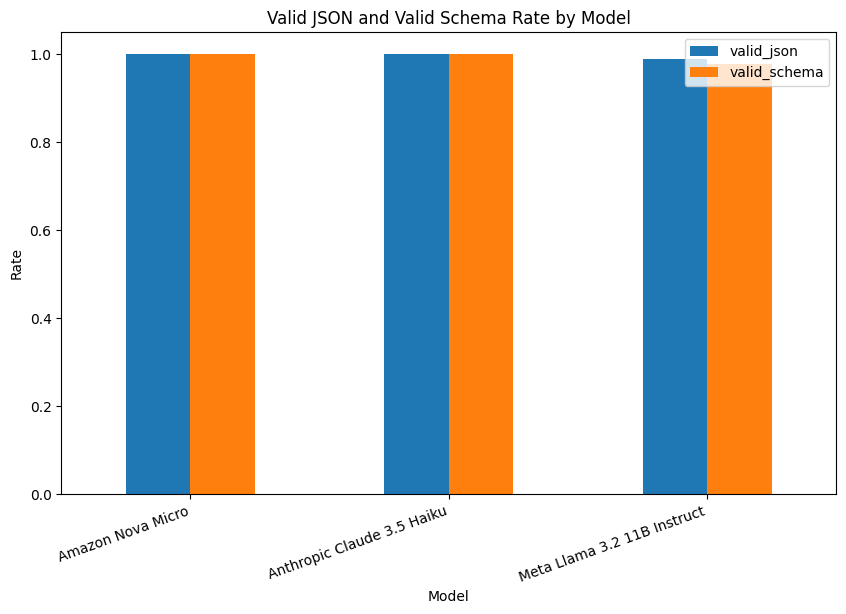

In [10]:
if is_results and {"valid_json", "valid_schema", "model_label"}.issubset(df.columns):
    quality = df.groupby("model_label")[["valid_json", "valid_schema"]].mean().sort_values("valid_json", ascending=False)
    ax = quality.plot(kind="bar")
    ax.set_title("Valid JSON and Valid Schema Rate by Model")
    ax.set_xlabel("Model")
    ax.set_ylabel("Rate")
    plt.xticks(rotation=20, ha="right")

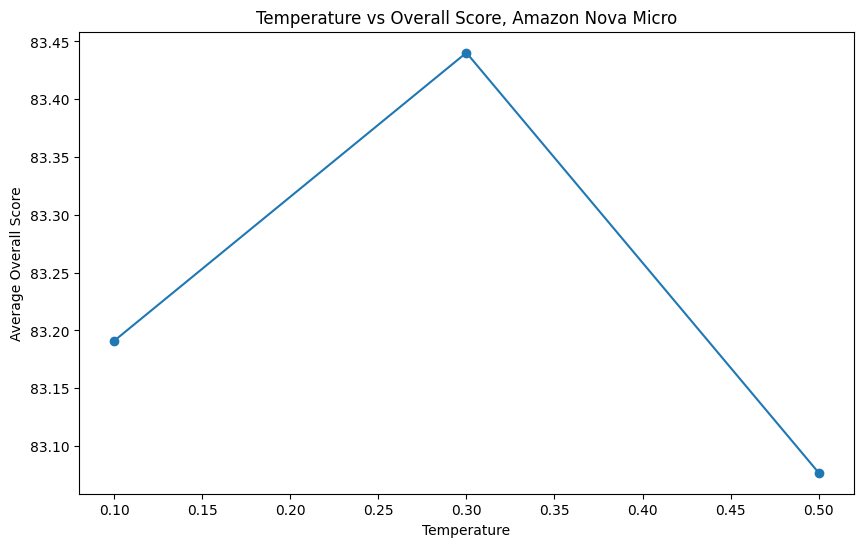

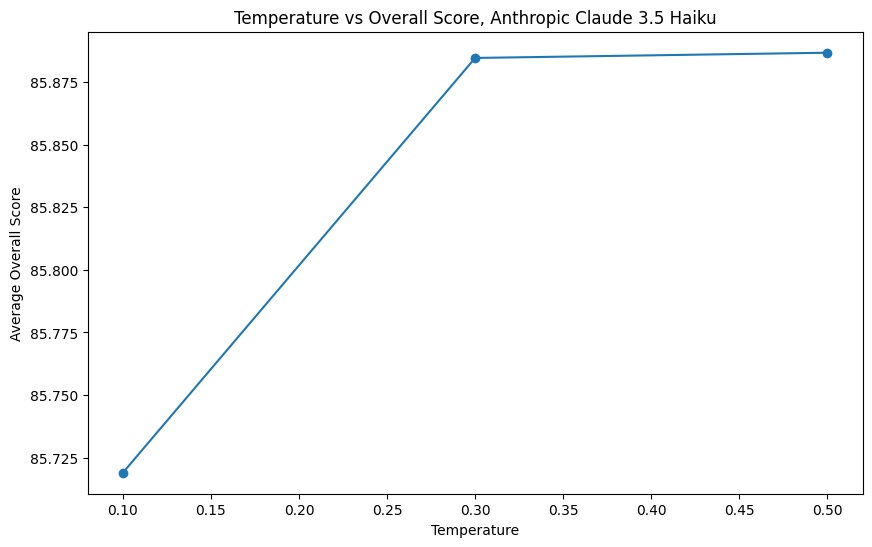

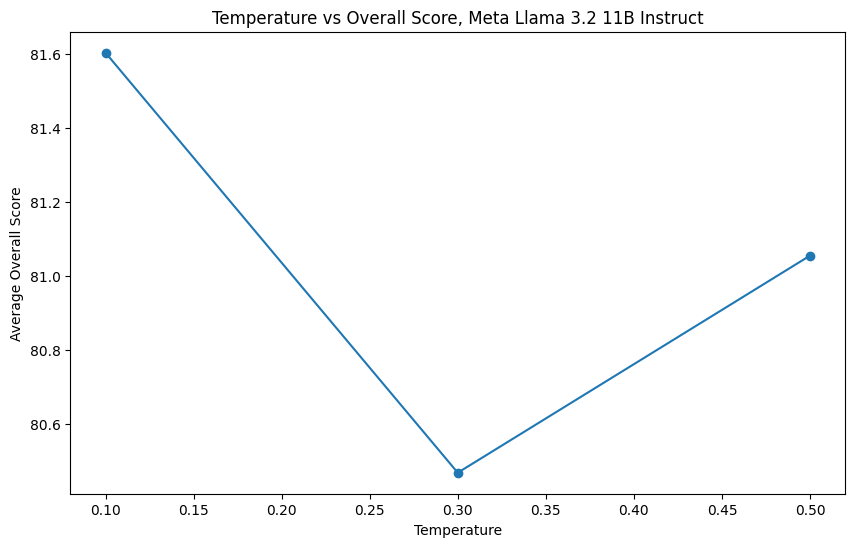

In [11]:
if is_results and {"temperature", "overall_score"}.issubset(df.columns):
    temp_score = (
        df.groupby(["model_label", "temperature"], dropna=False)["overall_score"]
        .mean()
        .reset_index()
    )
    for model_name, model_df in temp_score.groupby("model_label"):
        plt.figure()
        plt.plot(model_df["temperature"], model_df["overall_score"], marker="o")
        plt.title(f"Temperature vs Overall Score, {model_name}")
        plt.xlabel("Temperature")
        plt.ylabel("Average Overall Score")

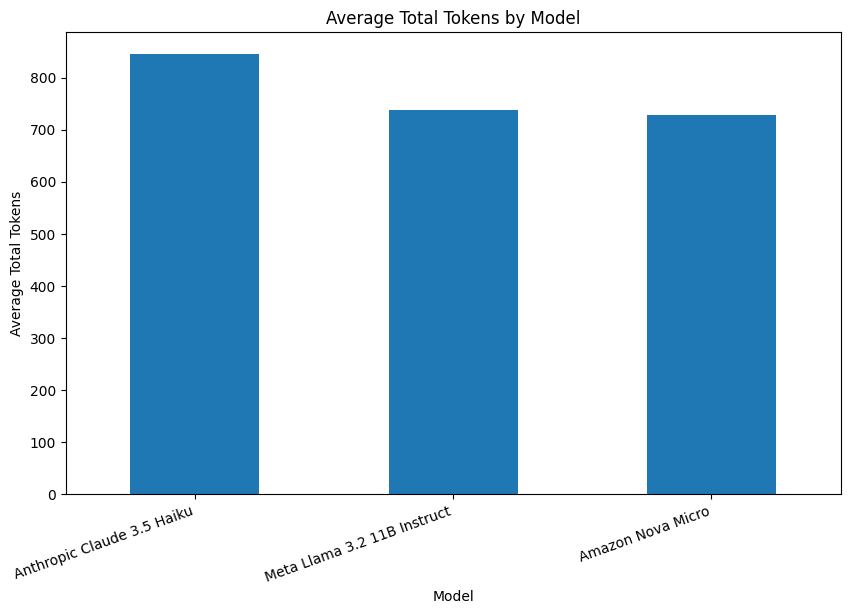

In [12]:
if is_results and {"total_tokens", "model_label"}.issubset(df.columns):
    tokens_by_model = (
        df.groupby("model_label", dropna=False)["total_tokens"]
        .mean()
        .sort_values(ascending=False)
    )
    grouped_bar(
        tokens_by_model,
        "Average Total Tokens by Model",
        "Model",
        "Average Total Tokens",
        "results_avg_total_tokens_by_model.png"
    )

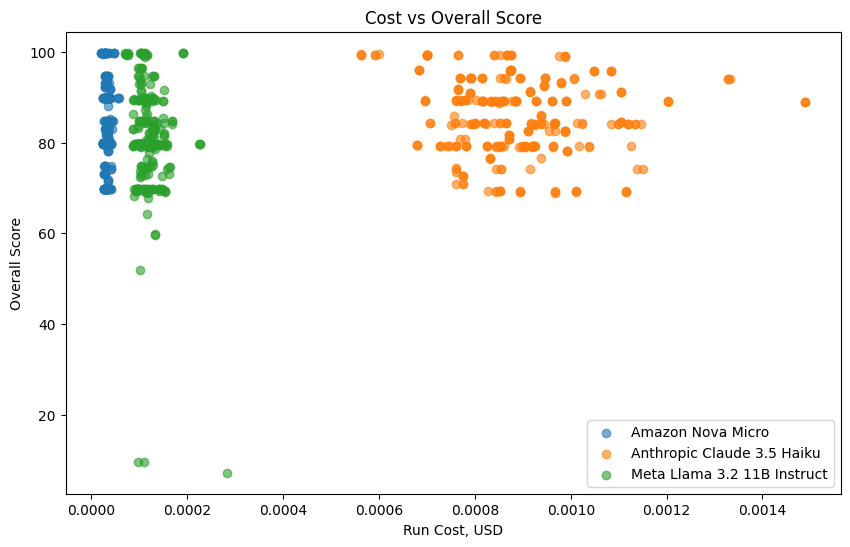

In [13]:
if is_results and {"run_cost_usd", "overall_score", "model_label"}.issubset(df.columns):
    plt.figure()
    for model_name, model_df in df.groupby("model_label"):
        plt.scatter(model_df["run_cost_usd"], model_df["overall_score"], alpha=0.6, label=model_name)
    plt.title("Cost vs Overall Score")
    plt.xlabel("Run Cost, USD")
    plt.ylabel("Overall Score")


    
    plt.legend()

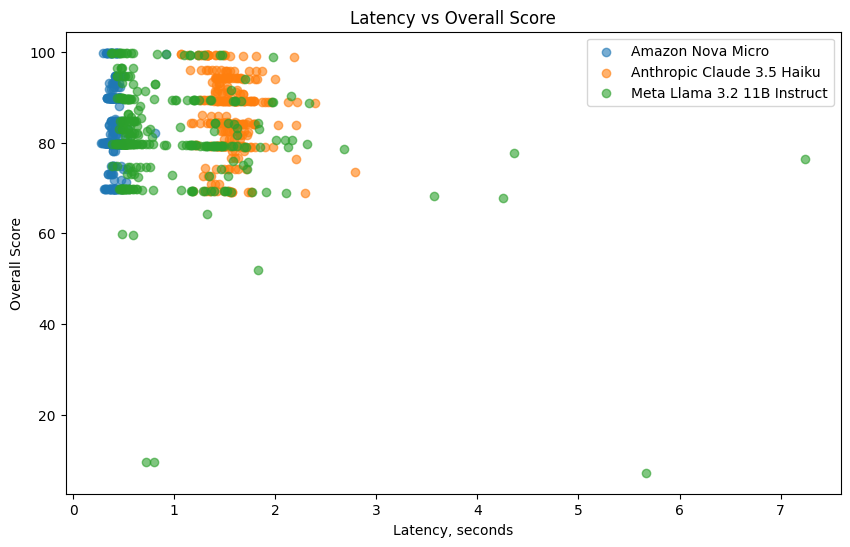

In [14]:
if is_results and {"latency_sec", "overall_score", "model_label"}.issubset(df.columns):
    plt.figure()
    for model_name, model_df in df.groupby("model_label"):
        plt.scatter(model_df["latency_sec"], model_df["overall_score"], alpha=0.6, label=model_name)
    plt.title("Latency vs Overall Score")
    plt.xlabel("Latency, seconds")
    plt.ylabel("Overall Score")
    plt.legend()

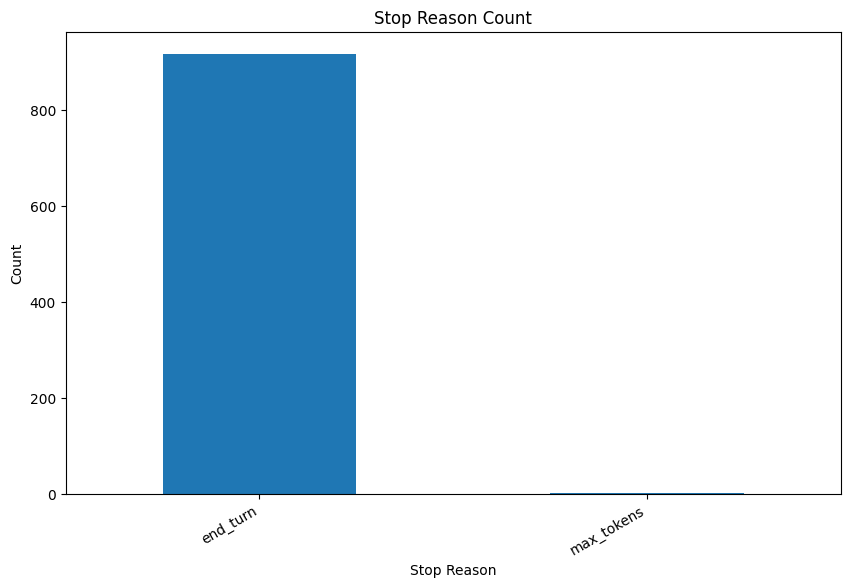

In [15]:
if is_results and safe_series_exists("stop_reason"):
    stop_reason_counts = df["stop_reason"].fillna("missing").value_counts()
    grouped_bar(
        stop_reason_counts,
        "Stop Reason Count",
        "Stop Reason",
        "Count",
        "results_stop_reason_count.png",
        rotation=30
    )

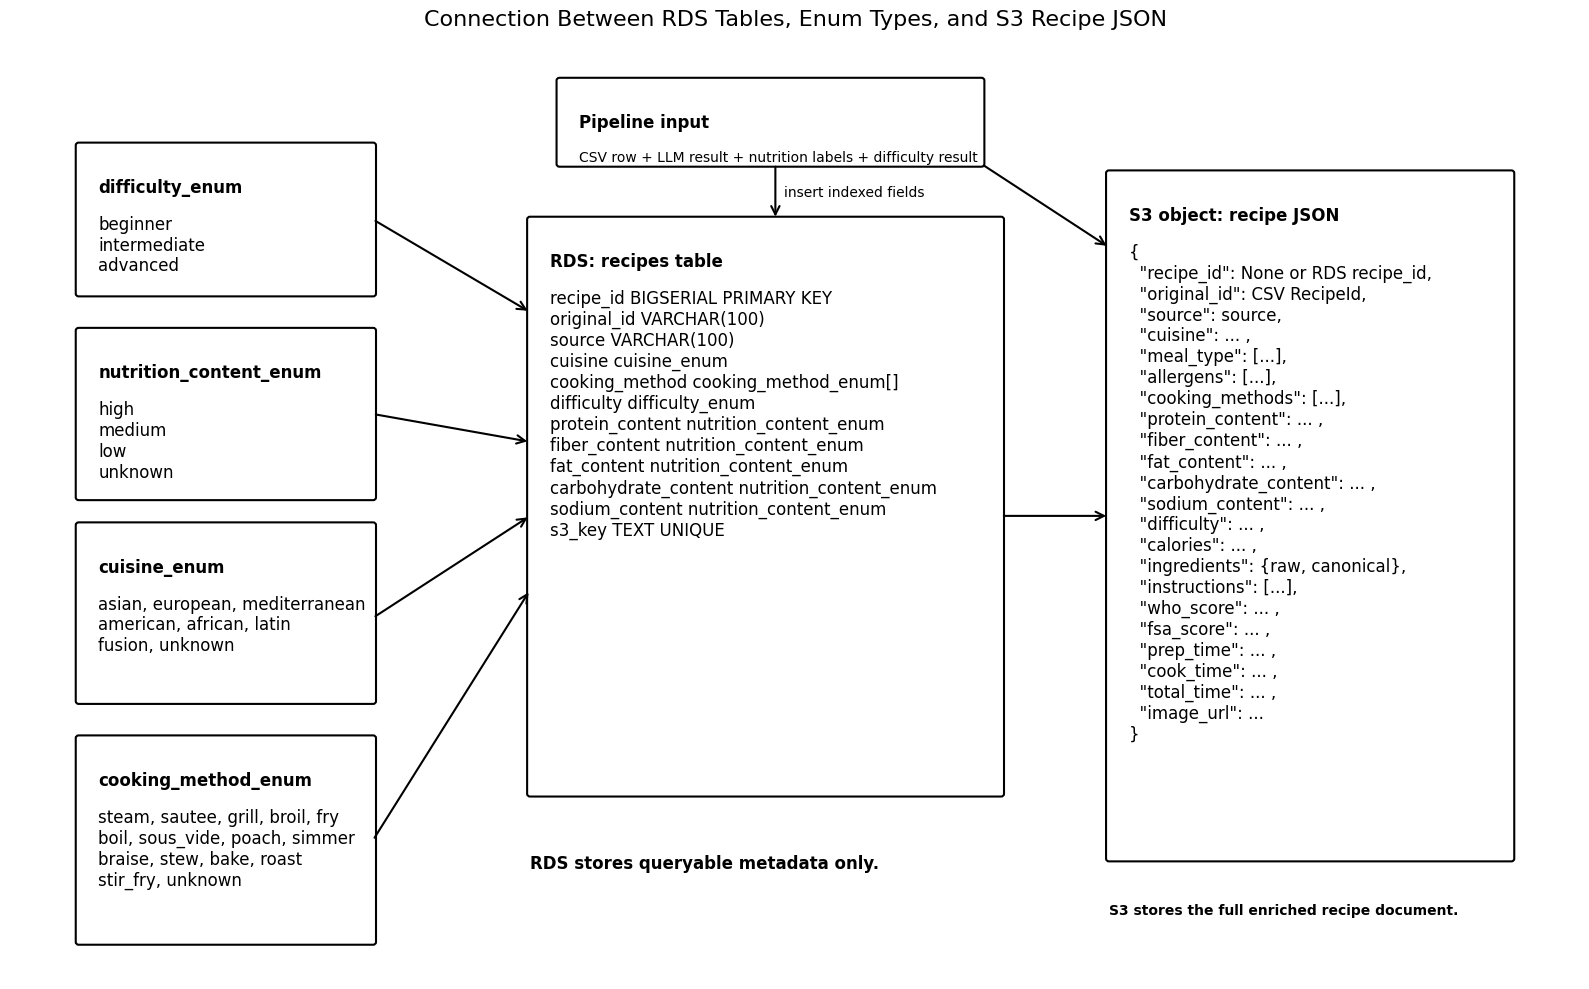

In [25]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(16, 10))
ax.set_xlim(0, 16)
ax.set_ylim(0, 10)
ax.axis("off")

def add_box(x, y, w, h, title, lines, fontsize=10):
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.03",
        linewidth=1.5,
        facecolor="white",
        edgecolor="black"
    )
    ax.add_patch(box)
    ax.text(x + 0.2, y + h - 0.35, title, fontsize=12, fontweight="bold", va="top")
    ax.text(x + 0.2, y + h - 0.75, "\n".join(lines), fontsize=fontsize, va="top")

def add_arrow(x1, y1, x2, y2, text=None, text_offset=(0, 0)):
    arrow = FancyArrowPatch(
        (x1, y1), (x2, y2),
        arrowstyle="->",
        mutation_scale=15,
        linewidth=1.5,
        color="black"
    )
    ax.add_patch(arrow)
    if text:
        ax.text(
            (x1 + x2) / 2 + text_offset[0],
            (y1 + y2) / 2 + text_offset[1],
            text,
            fontsize=10,
            ha="center",
            va="center"
        )

# Left side, enum types
add_box(
    0.7, 7.4, 3.0, 1.6,
    "difficulty_enum",
    [
        "beginner",
        "intermediate",
        "advanced"
    ],
    fontsize=12
)

add_box(
    0.7, 5.2, 3.0, 1.8,
    "nutrition_content_enum",
    [
        "high",
        "medium",
        "low",
        "unknown"
    ],
    fontsize=12
)

add_box(
    0.7, 3.0, 3.0, 1.9,
    "cuisine_enum",
    [
        "asian, european, mediterranean",
        "american, african, latin",
        "fusion, unknown"
    ],
    fontsize=12
)

add_box(
    0.7, 0.4, 3.0, 2.2,
    "cooking_method_enum",
    [
        "steam, sautee, grill, broil, fry",
        "boil, sous_vide, poach, simmer",
        "braise, stew, bake, roast",
        "stir_fry, unknown"
    ],
    fontsize=12
)

# Center, RDS recipes table
add_box(
    5.3, 2.0, 4.8, 6.2,
    "RDS: recipes table",
    [
        "recipe_id BIGSERIAL PRIMARY KEY",
        "original_id VARCHAR(100)",
        "source VARCHAR(100)",
        "cuisine cuisine_enum",
        "cooking_method cooking_method_enum[]",
        "difficulty difficulty_enum",
        "protein_content nutrition_content_enum",
        "fiber_content nutrition_content_enum",
        "fat_content nutrition_content_enum",
        "carbohydrate_content nutrition_content_enum",
        "sodium_content nutrition_content_enum",
        "s3_key TEXT UNIQUE"
    ],
    fontsize=12
)

# Right side, S3 JSON payload
add_box(
    11.2, 1.3, 4.1, 7.4,
    "S3 object: recipe JSON",
    [
        "{",
        '  "recipe_id": None or RDS recipe_id,',
        '  "original_id": CSV RecipeId,',
        '  "source": source,',
        '  "cuisine": ... ,',
        '  "meal_type": [...],',
        '  "allergens": [...],',
        '  "cooking_methods": [...],',
        '  "protein_content": ... ,',
        '  "fiber_content": ... ,',
        '  "fat_content": ... ,',
        '  "carbohydrate_content": ... ,',
        '  "sodium_content": ... ,',
        '  "difficulty": ... ,',
        '  "calories": ... ,',
        '  "ingredients": {raw, canonical},',
        '  "instructions": [...],',
        '  "who_score": ... ,',
        '  "fsa_score": ... ,',
        '  "prep_time": ... ,',
        '  "cook_time": ... ,',
        '  "total_time": ... ,',
        '  "image_url": ...',
        "}"
    ],
    fontsize=12
)

# Top note, input pipeline
add_box(
    5.6, 8.8, 4.3, 0.9,
    "Pipeline input",
    [
        "CSV row + LLM result + nutrition labels + difficulty result"
    ],
    fontsize=10
)

# Arrows from enums to recipes table
add_arrow(3.7, 8.2, 5.3, 7.2)
add_arrow(3.7, 6.1, 5.3, 5.8)
add_arrow(3.7, 3.9, 5.3, 5.0)
add_arrow(3.7, 1.5, 5.3, 4.2)

# Arrow from pipeline input to both storage targets
add_arrow(7.8, 8.8, 7.8, 8.2, "insert indexed fields", text_offset=(0.8, 0))
add_arrow(9.9, 8.8, 11.2, 7.9)

# Arrow from RDS to S3
add_arrow(10.1, 5.0, 11.2, 5.0)

# Bottom notes
ax.text(
    5.3, 1.2,
    "RDS stores queryable metadata only.",
    fontsize=12,
    fontweight="bold"
)
ax.text(
    11.2, 0.7,
    "S3 stores the full enriched recipe document.",
    fontsize=10,
    fontweight="bold"
)

plt.title("Connection Between RDS Tables, Enum Types, and S3 Recipe JSON", fontsize=16, pad=20)
plt.tight_layout()
plt.show()